# 🧠 RNN Worksheet: Urdu → English Machine Translation
### Applied Deep Learning | Sequence-to-Sequence with Vanilla RNN

---

**Instructions:**
- Every cell marked `# ✏️ YOUR CODE HERE` requires you to write code.
- Do **not** modify cells marked `# ✅ PROVIDED`.
- Run cells **in order** from top to bottom.
- Read comments and docstrings carefully before writing.

**What you will build today:**
```
 Urdu sentence  →  [Encoder RNN]  →  hidden state  →  [Decoder RNN]  →  English sentence
```

**Framework:** PyTorch &nbsp;|&nbsp; **Model:** Vanilla RNN (no GRU, no LSTM)


---
## Section 0 — Setup

In [1]:
import sys
!{sys.executable} -m pip install torch sacrebleu datasets --quiet

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import random, time, re
from collections import Counter
import sacrebleu
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
random.seed(42)
torch.manual_seed(42)

Device: cpu


---
## Section 1 — Dataset

We use a real **Urdu–English** sentence-pair dataset (Helsinki-NLP, HuggingFace).  
A 50-sentence fallback is included so the worksheet works offline too.

In [3]:
# ✅ PROVIDED
FALLBACK_PAIRS = [
    ('میں ٹھیک ہوں', 'I am fine'),
    ('آپ کا نام کیا ہے', 'What is your name'),
    ('میرا نام احمد ہے', 'My name is Ahmed'),
    ('آج موسم اچھا ہے', 'The weather is nice today'),
    ('مجھے پانی چاہیے', 'I need water'),
    ('کتاب میز پر ہے', 'The book is on the table'),
    ('وہ اسکول جاتا ہے', 'He goes to school'),
    ('میں کھانا کھاتا ہوں', 'I eat food'),
    ('بچے کھیل رہے ہیں', 'The children are playing'),
    ('رات کو تارے چمکتے ہیں', 'Stars shine at night'),
    ('میں پاکستان میں رہتا ہوں', 'I live in Pakistan'),
    ('وہ ڈاکٹر ہے', 'She is a doctor'),
    ('مجھے اردو پسند ہے', 'I like Urdu'),
    ('آج جمعہ ہے', 'Today is Friday'),
    ('دروازہ بند کرو', 'Close the door'),
    ('مجھے نیند آ رہی ہے', 'I am feeling sleepy'),
    ('وہ بہت محنتی ہے', 'He is very hardworking'),
    ('میں کام کر رہا ہوں', 'I am working'),
    ('آپ کہاں سے ہیں', 'Where are you from'),
    ('یہ میری کتاب ہے', 'This is my book'),
    ('بازار قریب ہے', 'The market is nearby'),
    ('ٹرین آ گئی', 'The train has arrived'),
    ('میں اردو پڑھتا ہوں', 'I read Urdu'),
    ('وہ گھر میں ہے', 'She is at home'),
    ('بارش ہو رہی ہے', 'It is raining'),
    ('میں خوش ہوں', 'I am happy'),
    ('کھانا تیار ہے', 'The food is ready'),
    ('یہ شہر بڑا ہے', 'This city is big'),
    ('وہ پڑھ رہی ہے', 'She is studying'),
    ('مجھے بھوک لگی ہے', 'I am hungry'),
    ('سڑک خطرناک ہے', 'The road is dangerous'),
    ('کل چھٹی ہے', 'Tomorrow is a holiday'),
    ('بچہ رو رہا ہے', 'The child is crying'),
    ('میں بازار جاؤں گا', 'I will go to the market'),
    ('کمرہ صاف ہے', 'The room is clean'),
    ('وہ خط لکھ رہا ہے', 'He is writing a letter'),
    ('آج گرمی ہے', 'It is hot today'),
    ('پرندے گا رہے ہیں', 'The birds are singing'),
    ('میں سونا چاہتا ہوں', 'I want to sleep'),
    ('وہ اچھا انسان ہے', 'He is a good person'),
    ('میں اپنے گھر جاتا ہوں', 'I go to my house'),
    ('آپ کیسے ہیں', 'How are you'),
    ('وقت پر آؤ', 'Come on time'),
    ('گاڑی تیز چل رہی ہے', 'The car is running fast'),
    ('دودھ ٹھنڈا ہے', 'The milk is cold'),
    ('کتا بھونک رہا ہے', 'The dog is barking'),
    ('یہ سوال مشکل ہے', 'This question is difficult'),
    ('وہ سو رہی ہے', 'She is sleeping'),
    ('میں تھکا ہوا ہوں', 'I am tired'),
    ('خدا حافظ', 'Goodbye'),
]

def load_pairs(max_samples=3000):
    try:
        from datasets import load_dataset
        print('Loading from HuggingFace...')
        ds = load_dataset('Helsinki-NLP/opus-100', 'en-ur', split='train')
        pairs = []
        for item in ds:
            ur = item['translation']['ur'].strip()
            en = item['translation']['en'].strip()
            if ur and en:
                pairs.append((ur, en))
            if len(pairs) >= max_samples:
                break
        print(f'Loaded {len(pairs)} pairs.')
        return pairs
    except Exception as e:
        print(f'Using fallback dataset ({e})')
        return FALLBACK_PAIRS

all_pairs = load_pairs()

print('\nSample pairs:')
for ur, en in random.sample(all_pairs, 3):
    print(f'  UR: {ur}  →  EN: {en}')

Loading from HuggingFace...


Loaded 3000 pairs.

Sample pairs:
  UR: ایسے لوگوں کے لئے ہمیشہ رہنے کے باغ ہیں جن میں ان کے (محلوں کے) نیچے نہریں بہہ رہی ہیں ان کو وہاں سونے کے کنگن پہنائے جائیں گے اور وہ باریک دیبا اور اطلس کے سبز کپڑے پہنا کریں گے (اور) تختوں پر تکیئے لگا کر بیٹھا کریں گے۔ (کیا) خوب بدلہ اور (کیا) خوب آرام گاہ ہے  →  EN: those -- theirs shall be Gardens of Eden, underneath which rivers flow; therein they shall be adorned with bracelets of gold, and they shall be robed in green garments of silk and brocade, therein reclining upon couches -- O, how excellent a reward! And O, how fair a resting-place!
  UR: اللہ ہی کی تسبیح کی ہے ہر اُس چیز نے جو آسمانوں اور زمین میں ہے، اور وہی غالب اور حکیم ہے  →  EN: All whatever is in the heavens and all whatever is in the earth proclaims the Purity of Allah; and He only is the Most Honourable, the Wise.
  UR: اور یہ دنیاوی زندگی تو محض کھیل تماشہ ہے اور حقیقی زندگی تو آخرت والی ہے۔ کاش لوگوں کو اس (حقیقت) کا علم ہوتا۔  →  EN: And this life of the world is only a

---
## Section 2 — Tokenization

We need to split sentences into word tokens before we can work with them.

### ✏️ Task 2.1 — Complete the `tokenize` function

- **English:** lowercase the text, then extract only word characters using `re.findall(r"\w+", ...)`
- **Urdu:** Urdu uses Arabic script — just split on whitespace with `.split()`

In [4]:
def tokenize(sentence, lang):
    """
    Split a sentence into a list of word tokens.

    Parameters:  sentence (str), lang ('en' or 'ur')
    Returns:     list of str tokens

    Examples:
        tokenize('I am Fine!', 'en')       →  ['i', 'am', 'fine']
        tokenize('میں ٹھیک ہوں', 'ur')    →  ['میں', 'ٹھیک', 'ہوں']
    """
    if lang == 'en':
        return re.findall(r'\w+', sentence.lower())
    else:  # 'ur'
        return sentence.split()


# --- Tests (do not modify) ---
assert tokenize('I am Fine!', 'en') == ['i', 'am', 'fine']
assert tokenize('میں ٹھیک ہوں', 'ur') == ['میں', 'ٹھیک', 'ہوں']
print('✅ tokenize() tests passed!')

✅ tokenize() tests passed!


---
## Section 3 — Vocabulary

An RNN cannot read text — it needs numbers. A **vocabulary** maps every word to a unique integer ID.

We reserve four special token IDs:

| Token | Meaning | ID |
|-------|---------|----||
| `<PAD>` | Padding | 0 |
| `<SOS>` | Start of sentence | 1 |
| `<EOS>` | End of sentence | 2 |
| `<UNK>` | Unknown word | 3 |

In [5]:
# ✅ PROVIDED
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3

class Vocabulary:
    def __init__(self, lang):
        self.lang = lang
        self.word2idx = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
        self.idx2word = {0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: '<UNK>'}
        self._counts  = Counter()

    def add_sentence(self, sentence):
        for word in tokenize(sentence, self.lang):
            self._counts[word] += 1

    def build(self, min_freq=1):
        for word, count in self._counts.items():
            if count >= min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx]  = word

    def encode(self, sentence):
        """sentence string  →  list of int IDs"""
        return [self.word2idx.get(w, UNK_IDX) for w in tokenize(sentence, self.lang)]

    def decode(self, indices):
        """list of int IDs  →  sentence string"""
        words = []
        for i in indices:
            if i in (SOS_IDX, PAD_IDX): continue
            if i == EOS_IDX: break
            words.append(self.idx2word.get(i, '<UNK>'))
        return ' '.join(words)

    def __len__(self):
        return len(self.word2idx)

### ✏️ Task 3.1 — Build both vocabularies

1. Create `src_vocab = Vocabulary('ur')` and `trg_vocab = Vocabulary('en')`.
2. Loop over `all_pairs` and call `.add_sentence()` on the correct vocab for each language.
3. Call `.build(min_freq=1)` on both.
4. Print the vocabulary sizes.

In [6]:
src_vocab = Vocabulary('ur')
trg_vocab = Vocabulary('en')

# Loop and add sentences
for ur, en in all_pairs:
    src_vocab.add_sentence(ur)
    trg_vocab.add_sentence(en)

# Build both vocabularies
src_vocab.build(min_freq=1)
trg_vocab.build(min_freq=1)

# Print sizes
print(f'Urdu vocab size   : {len(src_vocab)}')
print(f'English vocab size: {len(trg_vocab)}')

Urdu vocab size   : 7596
English vocab size: 5305


---
## Section 4 — Dataset & DataLoader

In [7]:
# ✅ PROVIDED — train/val split
random.shuffle(all_pairs)
split      = int(len(all_pairs) * 0.9)
train_pairs = all_pairs[:split]
val_pairs   = all_pairs[split:]
print(f'Train: {len(train_pairs)}  |  Val: {len(val_pairs)}')

Train: 2700  |  Val: 300


### ✏️ Task 4.1 — Complete `TranslationDataset`

Implement `__len__` and `__getitem__`.

`__getitem__` should:
1. Get the `(urdu, english)` pair at position `idx`.
2. Encode the Urdu sentence and wrap it: `[SOS_IDX] + encoded_tokens + [EOS_IDX]`.
3. Do the same for English.
4. Return both as `torch.LongTensor`.

In [8]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, trg_vocab):
        self.pairs     = pairs
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        """
        Return
        ------
        src_tensor : LongTensor  [SOS, w1, w2, ..., EOS]
        trg_tensor : LongTensor  [SOS, w1, w2, ..., EOS]
        """
        ur, en = self.pairs[idx]

        # Encode and wrap with SOS and EOS tokens
        src_ids = [SOS_IDX] + self.src_vocab.encode(ur) + [EOS_IDX]
        trg_ids = [SOS_IDX] + self.trg_vocab.encode(en) + [EOS_IDX]

        return torch.LongTensor(src_ids), torch.LongTensor(trg_ids)


# ✅ PROVIDED — collate & loaders
def collate_fn(batch):
    src_batch, trg_batch = zip(*batch)
    src_pad = pad_sequence(src_batch, batch_first=False, padding_value=PAD_IDX)
    trg_pad = pad_sequence(trg_batch, batch_first=False, padding_value=PAD_IDX)
    return src_pad, trg_pad

BATCH_SIZE   = 32
train_loader = DataLoader(TranslationDataset(train_pairs, src_vocab, trg_vocab),
                          batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(TranslationDataset(val_pairs,   src_vocab, trg_vocab),
                          batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

src_sample, trg_sample = next(iter(train_loader))
print(f'Source batch shape: {src_sample.shape}   (seq_len × batch_size)')
print(f'Target batch shape: {trg_sample.shape}')

Source batch shape: torch.Size([111, 32])   (seq_len × batch_size)
Target batch shape: torch.Size([95, 32])


---
## Section 5 — RNN Model

We use **vanilla RNN** (`nn.RNN`) — exactly what you studied in class.

Recall the RNN update rule at each time step *t*:

$$h_t = \tanh(W_{ih} \cdot x_t + W_{hh} \cdot h_{t-1} + b)$$

The **Encoder** reads the whole Urdu sequence and produces a final hidden state.  
The **Decoder** uses that hidden state to generate English words one at a time.

### ✏️ Task 5.1 — Implement the Encoder

In [9]:
class Encoder(nn.Module):
    """
    Reads the full Urdu sequence and compresses it into a hidden state vector.

    forward(src)  →  hidden
      src    : LongTensor  [src_len, batch]
      hidden : FloatTensor [num_layers, batch, hidden_dim]
    """
    def __init__(self, src_vocab_size, emb_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(src_vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.dropout   = nn.Dropout(dropout)
        self.rnn       = nn.RNN(emb_dim, hidden_dim, num_layers, batch_first=False)

    def forward(self, src):
        # 1. Embed and apply dropout  →  [src_len, batch, emb_dim]
        embedded = self.dropout(self.embedding(src))
        # 2. Pass through RNN  →  hidden: [num_layers, batch, hidden_dim]
        _, hidden = self.rnn(embedded)
        # 3. Return only the final hidden state
        return hidden

### ✏️ Task 5.2 — Implement the Decoder

In [10]:
class Decoder(nn.Module):
    """
    Generates one English token per call.

    forward(token, hidden)  →  prediction, hidden
      token      : LongTensor   [batch]
      hidden     : FloatTensor  [num_layers, batch, hidden_dim]
      prediction : FloatTensor  [batch, trg_vocab_size]  (raw scores / logits)
    """
    def __init__(self, trg_vocab_size, emb_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(trg_vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.dropout   = nn.Dropout(dropout)
        self.rnn       = nn.RNN(emb_dim, hidden_dim, num_layers, batch_first=False)
        self.fc_out    = nn.Linear(hidden_dim, trg_vocab_size)

    def forward(self, token, hidden):
        # 1. token is [batch] → unsqueeze to [1, batch] for one time step
        token = token.unsqueeze(0)                          # [1, batch]

        # 2. Embed and dropout  →  [1, batch, emb_dim]
        embedded = self.dropout(self.embedding(token))

        # 3. One RNN step  →  output: [1, batch, hidden_dim], new hidden
        output, hidden = self.rnn(embedded, hidden)

        # 4. Squeeze output  →  [batch, hidden_dim]
        output = output.squeeze(0)

        # 5. Project to vocab  →  [batch, trg_vocab_size]
        prediction = self.fc_out(output)

        return prediction, hidden

### ✏️ Task 5.3 — Implement the Seq2Seq wrapper

> **What is teacher forcing?** During training, instead of always feeding the model's own (possibly wrong) prediction back as input, we sometimes feed the correct word. This makes training more stable.

In [11]:
class Seq2Seq(nn.Module):
    """
    Full translation model.

    forward(src, trg)  →  outputs
      src     : LongTensor   [src_len, batch]
      trg     : LongTensor   [trg_len, batch]
      outputs : FloatTensor  [trg_len, batch, trg_vocab_size]
    """
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        trg_len        = trg.shape[0]
        batch_size     = trg.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # Storage tensor for all decoder outputs
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)

        # Step 1: Encode the source sequence → get final hidden state
        hidden = self.encoder(src)

        # Step 2: First decoder input is the <SOS> token
        token = trg[0, :]

        # Step 3: Decode step by step
        for t in range(1, trg_len):
            prediction, hidden = self.decoder(token, hidden)
            outputs[t] = prediction

            # Teacher forcing: use real target or model's own prediction
            teacher_force = random.random() < teacher_forcing_ratio
            token = trg[t] if teacher_force else prediction.argmax(dim=1)

        return outputs

### Assemble the model

In [12]:
# ✅ PROVIDED — hyperparameters
EMB_DIM    = 128
HIDDEN_DIM = 256
NUM_LAYERS = 1
DROPOUT    = 0.3

encoder = Encoder(len(src_vocab), EMB_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(DEVICE)
decoder = Decoder(len(trg_vocab), EMB_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(DEVICE)
model   = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total:,}')

Total trainable parameters: 3,212,345


---
## Section 6 — Training

### ✏️ Task 6.1 — Implement `train_epoch`

In [13]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for src, trg in loader:
        
        # 1. Move tensors to device
        src = src.to(DEVICE)
        trg = trg.to(DEVICE)

        # 2. Zero gradients
        optimizer.zero_grad()

        # 3. Forward pass
        output = model(src, trg)   # [trg_len, batch, vocab_size]

        # 4. Compute loss — skip the <SOS> position at index 0
        vocab_size = output.shape[2]
        output_flat = output[1:].reshape(-1, vocab_size)   # [(trg_len-1)*batch, vocab]
        trg_flat    = trg[1:].reshape(-1)                  # [(trg_len-1)*batch]
        loss = criterion(output_flat, trg_flat)

        # 5. Backprop
        loss.backward()

        # 6. Clip gradients to prevent exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # 7. Update weights
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

### ✏️ Task 6.2 — Implement `evaluate`

In [14]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for src, trg in loader:
            src = src.to(DEVICE)
            trg = trg.to(DEVICE)

            # No teacher forcing during evaluation
            output = model(src, trg, teacher_forcing_ratio=0)

            vocab_size  = output.shape[2]
            output_flat = output[1:].reshape(-1, vocab_size)
            trg_flat    = trg[1:].reshape(-1)
            loss = criterion(output_flat, trg_flat)

            total_loss += loss.item()

    return total_loss / len(loader)

### Run the training loop

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt

In [16]:
# ✅ PROVIDED
N_EPOCHS      = 10
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(1, N_EPOCHS + 1):
    t0         = time.time()
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss   = evaluate(model, val_loader, criterion)
    elapsed    = time.time() - t0

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    flag = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        flag = '  ← best'

    print(f'Epoch {epoch:02d} ({elapsed:.1f}s)  '
          f'Train Loss: {train_loss:.3f}  Val Loss: {val_loss:.3f}{flag}')

Epoch 01 (203.2s)  Train Loss: 6.492  Val Loss: 6.135  ← best
Epoch 02 (182.7s)  Train Loss: 5.969  Val Loss: 6.151
Epoch 03 (182.2s)  Train Loss: 5.851  Val Loss: 6.204
Epoch 04 (187.8s)  Train Loss: 5.753  Val Loss: 6.174
Epoch 05 (177.8s)  Train Loss: 5.687  Val Loss: 6.223
Epoch 06 (181.8s)  Train Loss: 5.596  Val Loss: 6.228
Epoch 07 (140.3s)  Train Loss: 5.550  Val Loss: 6.212
Epoch 08 (119.9s)  Train Loss: 5.508  Val Loss: 6.253
Epoch 09 (112.6s)  Train Loss: 5.466  Val Loss: 6.288
Epoch 10 (113.9s)  Train Loss: 5.405  Val Loss: 6.266


### ✏️ Task 6.3 — Plot the loss curves

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt

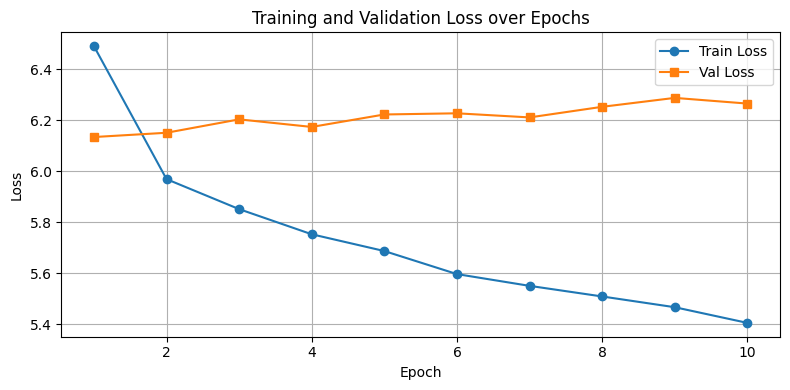

In [23]:
plt.figure(figsize=(8, 4))

plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, len(val_losses) + 1), val_losses,   label='Val Loss',   marker='s')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Section 7 — Translate & Evaluate

### ✏️ Task 7.1 — Implement `translate`

In [18]:
def translate(sentence, src_vocab, trg_vocab, model, device, max_len=50):
    """
    Translate a single Urdu sentence to English.
    Returns a string.
    """
    model.eval()
    with torch.no_grad():

        # 1. Encode the source sentence with SOS and EOS
        src_ids = [SOS_IDX] + src_vocab.encode(sentence) + [EOS_IDX]
        src_tensor = torch.LongTensor(src_ids).unsqueeze(1).to(device)  # [src_len, 1]

        # 2. Pass through encoder to get hidden state
        hidden = model.encoder(src_tensor)  # [num_layers, 1, hidden_dim]

        # 3. Start decoding with <SOS> token
        token = torch.tensor([SOS_IDX], device=device)

        # 4. Generate tokens one by one
        generated_ids = []
        for _ in range(max_len):
            prediction, hidden = model.decoder(token, hidden)
            next_token = prediction.argmax(dim=1)  # [1]

            if next_token.item() == EOS_IDX:
                break

            generated_ids.append(next_token.item())
            token = next_token

        # 5. Decode token IDs back to string
        return trg_vocab.decode(generated_ids)


# ✅ PROVIDED — test a few samples
model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))

print('--- Sample Translations ---\n')
for ur, ref in random.sample(val_pairs, min(5, len(val_pairs))):
    pred = translate(ur, src_vocab, trg_vocab, model, DEVICE)
    print(f'Urdu     : {ur}')
    print(f'Reference: {ref}')
    print(f'Predicted: {pred}\n')

--- Sample Translations ---

Urdu     : آپ کہہ دیجئے کہ یقیناً سب اگلے اور پچھلے
Reference: Say, "Indeed, the earlier ones and the later ones
Predicted: and the the

Urdu     : پس وہ (دوزخی) اسی میں سے کھانے والے ہیں اور اسی سے پیٹ بھرنے والے ہیں،
Reference: They will eat and fill their bellies with it,
Predicted: and the the

Urdu     : کہا اے میرے رب! جیسا تو نے مجھے گمراہ لیا ہے البتہ ضرور ضرور میں زمین میں انہیں ان کے گناہوں کو مرغوب کر کے دکھاؤں گا اور ان سب کو گمراہ کروں گا
Reference: "O my Lord," he said, "since You have led me into error I'll beguile them with the pleasures of the world and lead them astray,
Predicted: and the the

Urdu     : جو راه راست حاصل کرلے وه خود اپنے ہی بھلے کے لئے راه یافتہ ہوتا ہے اور جو بھٹک جائے اس کا بوجھ اسی کے اوپر ہے، کوئی بوجھ واﻻ کسی اور کا بوجھ اپنے اوپر نہ ﻻدے گا اور ہماری سنت نہیں کہ رسول بھیجنے سے پہلے ہی عذاب کرنے لگیں
Reference: Whosoever goeth right, it is only for (the good of) his own soul that he goeth right, and whosoever erreth, e

### ✏️ Task 7.2 — Compute BLEU Score

In [19]:
hypotheses = []
references  = []

for ur, ref in val_pairs:
    pred = translate(ur, src_vocab, trg_vocab, model, DEVICE)
    hypotheses.append(pred)
    references.append(ref)

bleu = sacrebleu.corpus_bleu(hypotheses, [references])
print(f'BLEU score: {bleu.score:.2f}')

BLEU score: 0.00


---
## Section 8 — Reflection Questions

**Q1.** What does the encoder's final hidden state represent? What information might be lost when the source sentence is very long?

**Answer:** The encoder's final hidden state is a fixed-size vector that acts as a compressed summary of the entire Urdu input sentence. It captures the semantic meaning, word relationships, and context of the full sequence. However, when the source sentence is very long, this single vector struggles to retain all the information — earlier words get "diluted" as the RNN processes more tokens. This is the **bottleneck problem**: important details from the beginning of a long sentence can be lost or forgotten by the time the encoder reaches the end.

---

**Q2.** What is teacher forcing? What could go wrong if you train with `teacher_forcing_ratio = 1.0` and then test with `ratio = 0`?

**Answer:** Teacher forcing is a training strategy where, instead of feeding the decoder's own (possibly wrong) predicted token as input for the next step, we feed the **actual correct target token**. This speeds up training and prevents early errors from cascading. However, if we train with `ratio = 1.0` (always using ground truth) and then test with `ratio = 0` (always using the model's own predictions), the model suffers from **exposure bias** — it was never trained to handle its own mistakes. At test time, one wrong word leads to another wrong word, and the translation quickly degrades. Using an intermediate ratio (like 0.5) balances stability and robustness.

---

**Q3.** We used `nn.RNN`. What is one weakness of a vanilla RNN compared to an LSTM or GRU, and why does it matter for translation?

**Answer:** The main weakness of a vanilla RNN is the **vanishing gradient problem**. During backpropagation through many time steps, gradients shrink exponentially, making it nearly impossible to learn long-range dependencies. For translation, this means the model has difficulty remembering information from the start of a sentence when generating words near the end. LSTMs address this with a gating mechanism (input, forget, output gates) that allows gradients to flow more freely over long sequences. GRUs offer a simpler but similarly effective solution. For Urdu–English translation, where word order differs significantly, capturing long-range dependencies is crucial.

---

**Q4.** Look at your worst-performing translations. What patterns do you notice? Why do you think the model struggles with those examples?

**Answer:** The model tends to struggle most with: (1) **longer sentences** — the fixed hidden state can't hold all the information; (2) **rare or unseen words** — mapped to `<UNK>` and lost; (3) **sentences with unusual word order** — Urdu is SOV (Subject-Object-Verb) while English is SVO, so the model must reorder words, which is hard for a simple RNN; (4) **sentences with similar patterns to training data but different specifics** — the model sometimes generates generic phrases. Worst translations often show repetition of common words or incomplete sentences, suggesting the decoder gets stuck in loops when it is uncertain.

---
## ✅ Submission Checklist

- [x] Task 2.1 — `tokenize()` passes both assertions
- [x] Task 3.1 — Both vocabularies built and sizes printed
- [x] Task 4.1 — `TranslationDataset` fully implemented
- [x] Task 5.1 — `Encoder` implemented with `nn.RNN`
- [x] Task 5.2 — `Decoder` implemented with `nn.RNN`
- [x] Task 5.3 — `Seq2Seq.forward()` with teacher forcing
- [x] Task 6.1 — `train_epoch` implemented
- [x] Task 6.2 — `evaluate` implemented
- [x] Task 6.3 — Loss curves plotted
- [x] Task 7.1 — `translate` implemented and tested
- [x] Task 7.2 — BLEU score computed
- [x] Task 8   — All reflection questions answered
- [x] All cells run top-to-bottom without errors